Loaded 9000 rows
Filtered distribution:
metabolic_potential_filtered
neither        5115
dnra           2011
denitrifier    1544
both            330
Name: count, dtype: int64


/var/folders/_1/szp4571s76d__d0kyyc1stgc0000gn/T/ipykernel_11241/393376387.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


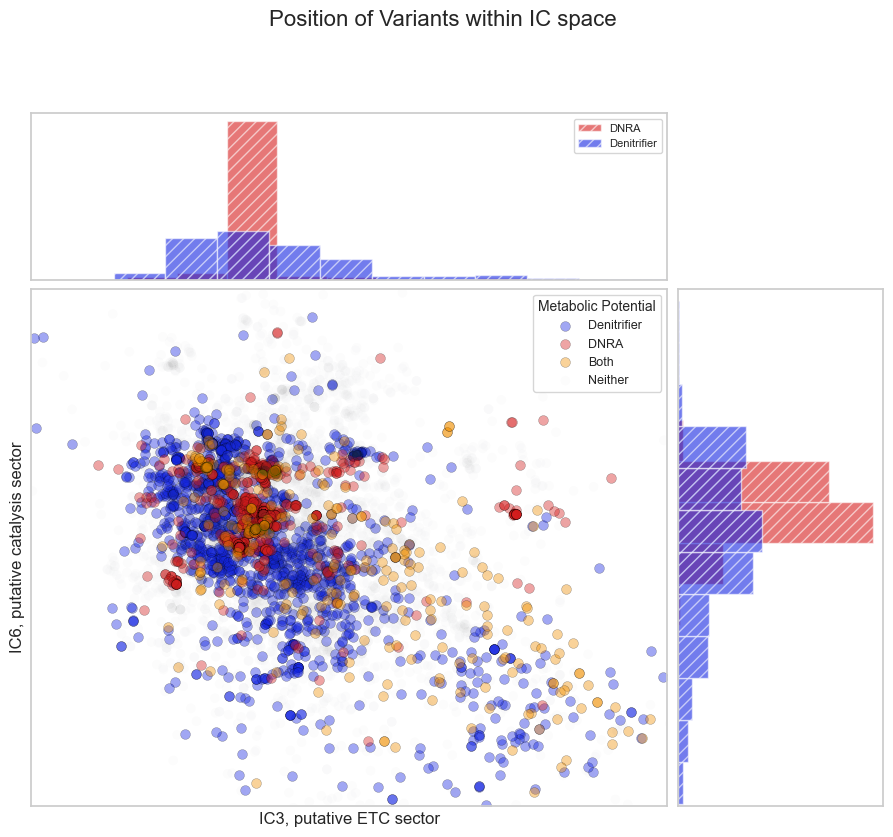

In [133]:
# %% [markdown]
# # Nitrogen Cycle Metabolic Potential Visualization
# Plotting Up3 vs Up6 with marginal histograms for DNRA & Denitrifier densities

# %%
# ================= CONFIGURATION =================
STRICT_DNRA = True         # True = only nrfA counts; False = nrfA OR nirB
STRICT_DENITRIFIER = False  # True = only nirK counts; False = nirK OR nosZ
SHOW_MARGINALS = True       # Toggle histograms on/off
MARGINAL_BINS = 100         # Number of bins for marginal histograms (higher = finer resolution)
# =====================================================

# %%
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Set plot style
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 7)

# %%
# Load the annotated data
df = pd.read_csv("../data/sca_df_annotated.csv")
print(f"Loaded {len(df)} rows")

# %%
# Helper function: Recalculate metabolic potential based on strict/lenient rules
def recalculate_metabolic_potential(row, strict_dnra=True, strict_denit=True):
    dnra_genes = set(row.get('genes_found_dnra', '').split(',')) if pd.notna(row.get('genes_found_dnra')) else set()
    denit_genes = set(row.get('genes_found_denitrifier', '').split(',')) if pd.notna(row.get('genes_found_denitrifier')) else set()
    dnra_genes.discard(''); denit_genes.discard('')
    
    if strict_dnra:
        dnra_present = 'nrfA' in dnra_genes
    else:
        dnra_present = bool(dnra_genes & {'nrfA', 'nirB'})
    
    if strict_denit:
        denit_present = 'nirK' in denit_genes
    else:
        denit_present = bool(denit_genes & {'nirK', 'nosZ'})
    
    if dnra_present and denit_present:
        return "both"
    elif dnra_present:
        return "dnra"
    elif denit_present:
        return "denitrifier"
    else:
        return "neither"

df['metabolic_potential_filtered'] = df.apply(
    recalculate_metabolic_potential, 
    axis=1, 
    strict_dnra=STRICT_DNRA, 
    strict_denit=STRICT_DENITRIFIER
)

print(f"Filtered distribution:\n{df['metabolic_potential_filtered'].value_counts()}")

# %%
ICA = 'Up3'
ICB = 'Up6'
plot_df = df.dropna(subset=[ICA, ICB, 'metabolic_potential_filtered']).copy()
plot_df['metabolic_potential_filtered'] = plot_df['metabolic_potential_filtered'].astype('category')
marginal_df = plot_df[plot_df['metabolic_potential_filtered'].isin(['dnra', 'denitrifier'])].copy()

# %%
# Create the plot with marginal histograms
if SHOW_MARGINALS:
    fig = plt.figure(figsize=(11, 9))
    gs = GridSpec(4, 4, figure=fig, hspace=0.05, wspace=0.05)
    
    ax_main = fig.add_subplot(gs[1:, :-1])
    ax_top = fig.add_subplot(gs[0, :-1], sharex=ax_main)
    ax_right = fig.add_subplot(gs[1:, -1], sharey=ax_main)
    
    plt.setp(ax_top.get_xticklabels(), visible=False)
    plt.setp(ax_right.get_yticklabels(), visible=False)
    
    # ===== MAIN SCATTER PLOT =====
    category_styles = {
        "denitrifier": {"color": "#1425E2", "alpha": 0.4, "label": "Denitrifier"},
        "dnra":        {"color": "#D61D1D", "alpha": 0.4, "label": "DNRA"},
        "both":        {"color": "#F18F01", "alpha": 0.4, "label": "Both"},
        "neither":     {"color": "#4F5152", "alpha": 0.01, "label": "Neither"}
    }
    
    for category, style in category_styles.items():
        subset = plot_df[plot_df['metabolic_potential_filtered'] == category]
        ax_main.scatter(
            subset[ICA], subset[ICB],
            label=style['label'],
            color=style['color'],
            alpha=style['alpha'],
            s=50,
            edgecolor='black' if category != 'neither' else 'none',
            linewidth=0.3
        )
    
    ax_main.set_xlabel('IC3, putative ETC sector', fontsize=12)
    ax_main.set_ylabel('IC6, putative catalysis sector', fontsize=12)
    ax_main.set_xlim(-0.021, -0.014)
    ax_main.set_ylim(0.017, 0.026)
    ax_main.set_xticks([])
    ax_main.set_yticks([])
    ax_main.grid(True, linestyle='--', alpha=0.4)
    ax_main.legend(title="Metabolic Potential", fontsize=9, title_fontsize=10)
    
    # ===== MARGINAL HISTOGRAMS =====
    # Top marginal: density along Up3 (x-axis)
    if len(marginal_df[marginal_df['metabolic_potential_filtered'] == 'dnra']) > 0:
        ax_top.hist(
            marginal_df[marginal_df['metabolic_potential_filtered'] == 'dnra'][ICA],
            bins=MARGINAL_BINS, color='#D61D1D', alpha=0.6, label='DNRA', density=True, hatch='///'
        )
    if len(marginal_df[marginal_df['metabolic_potential_filtered'] == 'denitrifier']) > 0:
        ax_top.hist(
            marginal_df[marginal_df['metabolic_potential_filtered'] == 'denitrifier'][ICA],
            bins=MARGINAL_BINS, color='#1425E2', alpha=0.6, label='Denitrifier', density=True,
            hatch='///'
        )
    # ax_top.set_ylabel('Density', fontsize=9)
    ax_top.legend(fontsize=8, loc='upper right')
    ax_top.grid(True, linestyle='--', alpha=0.3)
    ax_top.set_yticks([])
    
    # Right marginal: density along Up6 (y-axis)
    if len(marginal_df[marginal_df['metabolic_potential_filtered'] == 'dnra']) > 0:
        ax_right.hist(
            marginal_df[marginal_df['metabolic_potential_filtered'] == 'dnra'][ICB],
            bins=MARGINAL_BINS, color='#D61D1D', alpha=0.6, orientation='horizontal',
            label='DNRA', density=True, hatch='///'
        )
    if len(marginal_df[marginal_df['metabolic_potential_filtered'] == 'denitrifier']) > 0:
        ax_right.hist(
            marginal_df[marginal_df['metabolic_potential_filtered'] == 'denitrifier'][ICB],
            bins=MARGINAL_BINS, color='#1425E2', alpha=0.6, orientation='horizontal',
            label='Denitrifier', density=True, hatch='///'
        )
    # ax_right.set_xlabel('Density', fontsize=9)
    ax_right.grid(True, linestyle='--', alpha=0.3)
    ax_right.set_xticks([])
    
    # Title only (no footer note)
    fig.suptitle('Position of Variants within IC space', fontsize=16, fontname='Arial', y=0.995)
    
    plt.tight_layout()
    plt.show()
    
else:
    # Fallback: simple scatter plot without marginals
    plt.figure(figsize=(10, 7))
    for category, style in category_styles.items():
        subset = plot_df[plot_df['metabolic_potential_filtered'] == category]
        plt.scatter(
            subset[ICA], subset[ICB],
            label=style['label'],
            color=style['color'],
            alpha=style['alpha'],
            s=50,
            edgecolor='black' if category != 'neither' else 'none',
            linewidth=0.3
        )
    plt.title('Position of Variants within IC space', fontsize=18, fontname='Arial')
    plt.xlabel('IC3, putative ETC sector')
    plt.ylabel('IC6, putative catalysis sector')
    plt.xlim(-0.021, -0.014)
    plt.ylim(0.017, 0.026)
    plt.xticks([]); plt.yticks([])
    plt.legend(title="Metabolic Potential")
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

Phylum distribution (grouped, min_count=50):
phylum_grouped
Pseudomonadota             5106
Actinomycetota             2197
Bacillota                  1015
Other                       303
Unassigned                  168
Bacteroidota                107
Chloroflexota                53
Thermodesulfobacteriota      51
Name: count, dtype: int64


/var/folders/_1/szp4571s76d__d0kyyc1stgc0000gn/T/ipykernel_11241/2471068680.py:50: UserWarning: The palette list has more values (20) than needed (8), which may not be intended.
  scatter = sns.scatterplot(


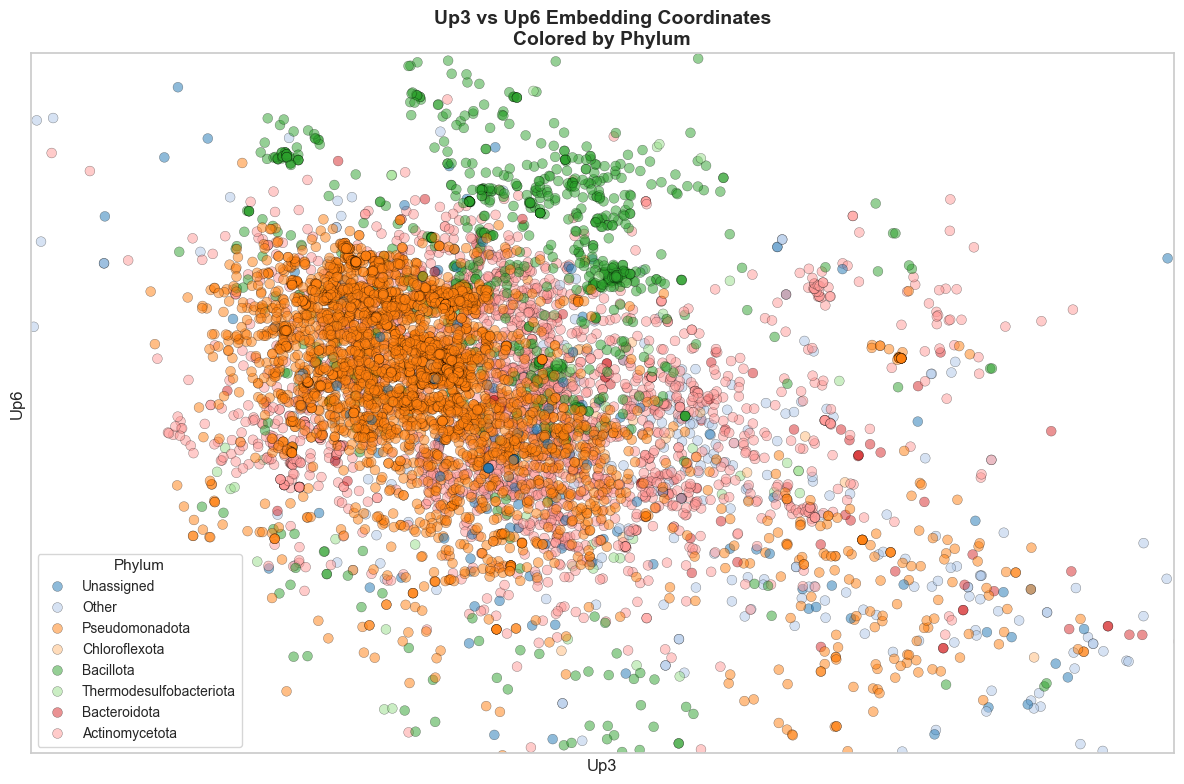

In [84]:
# %% [markdown]
# # Up3 vs Up6 Colored by Phylum
# Visualizing embedding space with taxonomic context

# %%
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plot style
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 7)

# %%
# Load the annotated data
df = pd.read_csv("../data/sca_df_annotated.csv")

# %%
# Prepare the phylum column for plotting
plot_df = df.dropna(subset=['Up3', 'Up6']).copy()

# Clean phylum column: fill empty strings and NaN with 'Unassigned'
plot_df['phylum_clean'] = plot_df['phylum'].fillna('').replace('', 'Unassigned')

# Optional: Group rare phyla into "Other" to avoid legend clutter
# Adjust min_count as needed (e.g., show top 10 phyla)
min_count = 50  
phylum_counts = plot_df['phylum_clean'].value_counts()
common_phyla = phylum_counts[phylum_counts >= min_count].index

plot_df['phylum_grouped'] = plot_df['phylum_clean'].apply(
    lambda x: x if x in common_phyla else 'Other'
)

print(f"Phylum distribution (grouped, min_count={min_count}):")
print(plot_df['phylum_grouped'].value_counts())

# %%
# Create the scatter plot colored by phylum
plt.figure(figsize=(12, 8))

# Use a palette that supports many categories
# 'tab20' supports up to 20 distinct colors; 'hls' generates unlimited distinct hues
unique_phyla = plot_df['phylum_grouped'].nunique()
palette = sns.color_palette("tab20" if unique_phyla <= 20 else "hls", 
                            n_colors=max(unique_phyla, 20))

scatter = sns.scatterplot(
    data=plot_df,
    x='Up3',
    y='Up6',
    hue='phylum_grouped',
    palette=palette,
    alpha=0.5,
    s=50,
    edgecolor='black',
    linewidth=0.3
)

# Customize legend: place outside plot if many categories
if unique_phyla > 10:
    plt.legend(title='Phylum', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title_fontsize=10)
else:
    plt.legend(title='Phylum', fontsize=10, title_fontsize=11)

plt.title("Up3 vs Up6 Embedding Coordinates\nColored by Phylum", fontsize=14, fontweight='bold')
plt.xlabel("Up3", fontsize=12)
plt.ylabel("Up6", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)

plt.xlim(-0.021, -0.014)
plt.ylim(0.017,0.026)
plt.xticks([])
plt.yticks([])

# Tight layout to accommodate external legend
plt.tight_layout()
plt.show()

Phylum distribution (grouped, min_count=50):
phylum_grouped
Pseudomonadota             5106
Actinomycetota             2197
Bacillota                  1015
Other                       303
Unassigned                  168
Bacteroidota                107
Chloroflexota                53
Thermodesulfobacteriota      51
Name: count, dtype: int64


/var/folders/_1/szp4571s76d__d0kyyc1stgc0000gn/T/ipykernel_11241/1630840284.py:50: UserWarning: The palette list has more values (20) than needed (8), which may not be intended.
  scatter = sns.scatterplot(


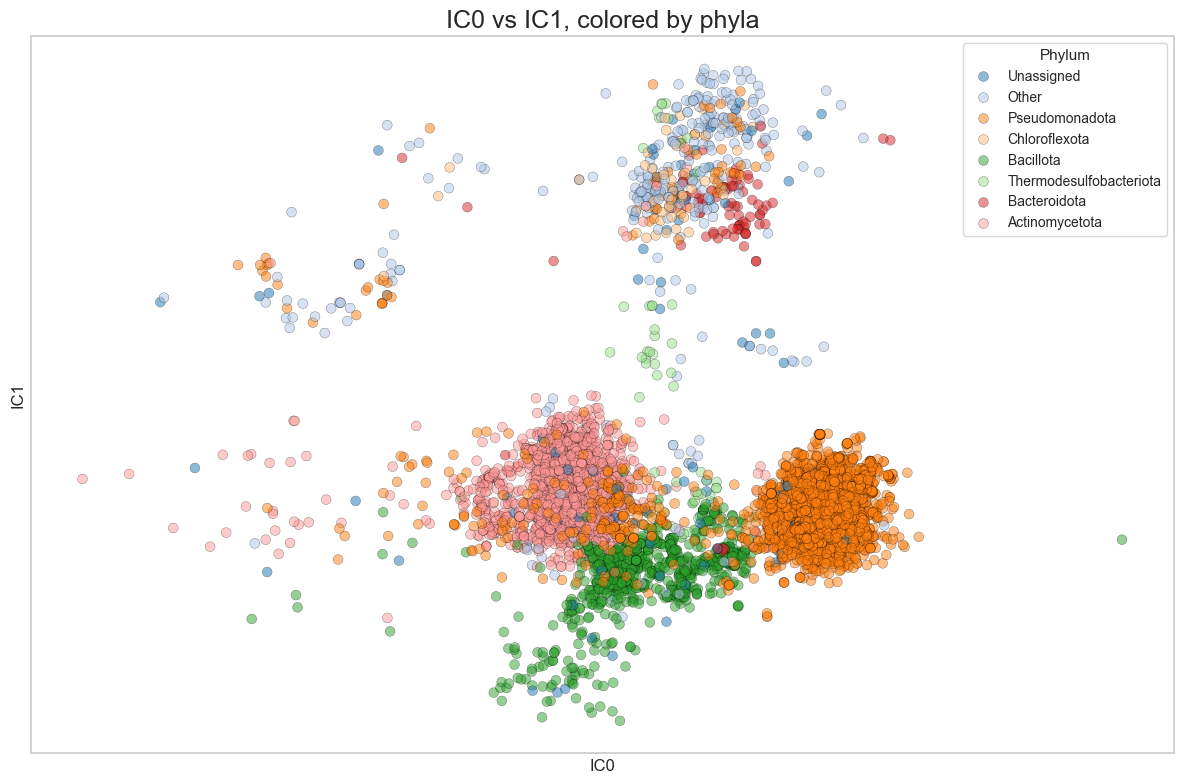

In [77]:
# %% [markdown]
# # Up3 vs Up6 Colored by Phylum
# Visualizing embedding space with taxonomic context

# %%
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plot style
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 7)

# %%
# Load the annotated data
df = pd.read_csv("../data/sca_df_annotated.csv")

# %%
# Prepare the phylum column for plotting
plot_df = df.dropna(subset=['Up3', 'Up6']).copy()

# Clean phylum column: fill empty strings and NaN with 'Unassigned'
plot_df['phylum_clean'] = plot_df['phylum'].fillna('').replace('', 'Unassigned')

# Optional: Group rare phyla into "Other" to avoid legend clutter
# Adjust min_count as needed (e.g., show top 10 phyla)
min_count = 50  
phylum_counts = plot_df['phylum_clean'].value_counts()
common_phyla = phylum_counts[phylum_counts >= min_count].index

plot_df['phylum_grouped'] = plot_df['phylum_clean'].apply(
    lambda x: x if x in common_phyla else 'Other'
)

print(f"Phylum distribution (grouped, min_count={min_count}):")
print(plot_df['phylum_grouped'].value_counts())

# %%
# Create the scatter plot colored by phylum
plt.figure(figsize=(12, 8))

# Use a palette that supports many categories
# 'tab20' supports up to 20 distinct colors; 'hls' generates unlimited distinct hues
unique_phyla = plot_df['phylum_grouped'].nunique()
palette = sns.color_palette("tab20" if unique_phyla <= 20 else "hls", 
                            n_colors=max(unique_phyla, 20))

scatter = sns.scatterplot(
    data=plot_df,
    x='Up0',
    y='Up1',
    hue='phylum_grouped',
    palette=palette,
    alpha=0.5,
    s=50,
    edgecolor='black',
    linewidth=0.3
)

# Customize legend: place outside plot if many categories
if unique_phyla > 10:
    plt.legend(title='Phylum', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title_fontsize=10)
else:
    plt.legend(title='Phylum', fontsize=10, title_fontsize=11)

plt.title("IC0 vs IC1, colored by phyla", fontsize=18, fontname = 'Arial')
plt.xlabel("IC0", fontsize=12)
plt.ylabel("IC1", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)


plt.xticks([])
plt.yticks([])

# Tight layout to accommodate external legend
plt.tight_layout()
plt.show()

Loaded 9000 rows
Filtered distribution:
metabolic_potential_filtered
neither        5115
dnra           2011
denitrifier    1544
both            330
Name: count, dtype: int64


/var/folders/_1/szp4571s76d__d0kyyc1stgc0000gn/T/ipykernel_11241/3356742305.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


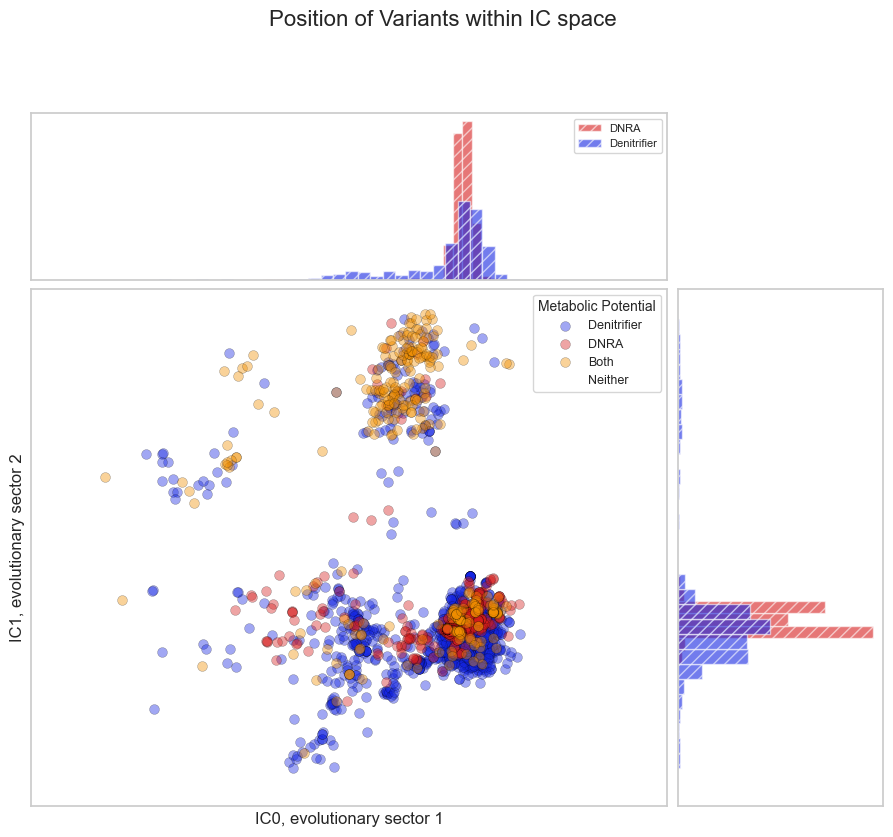

In [134]:
# %% [markdown]
# # Nitrogen Cycle Metabolic Potential Visualization
# Plotting Up3 vs Up6 with marginal histograms for DNRA & Denitrifier densities

# %%
# ================= USER CONFIGURATION =================
STRICT_DNRA = True          # True = only nrfA counts; False = nrfA OR nirB
STRICT_DENITRIFIER = False  # True = only nirK counts; False = nirK OR nosZ
SHOW_MARGINALS = True       # Toggle histograms on/off
MARGINAL_BINS = 30          # Number of bins for marginal histograms (higher = finer resolution)
# =====================================================

# %%
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Set plot style
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 7)

# %%
# Load the annotated data
df = pd.read_csv("../data/sca_df_annotated.csv")
print(f"Loaded {len(df)} rows")

# %%
# Helper function: Recalculate metabolic potential based on strict/lenient rules
def recalculate_metabolic_potential(row, strict_dnra=True, strict_denit=True):
    dnra_genes = set(row.get('genes_found_dnra', '').split(',')) if pd.notna(row.get('genes_found_dnra')) else set()
    denit_genes = set(row.get('genes_found_denitrifier', '').split(',')) if pd.notna(row.get('genes_found_denitrifier')) else set()
    dnra_genes.discard(''); denit_genes.discard('')
    
    if strict_dnra:
        dnra_present = 'nrfA' in dnra_genes
    else:
        dnra_present = bool(dnra_genes & {'nrfA', 'nirB'})
    
    if strict_denit:
        denit_present = 'nirK' in denit_genes
    else:
        denit_present = bool(denit_genes & {'nirK', 'nosZ'})
    
    if dnra_present and denit_present:
        return "both"
    elif dnra_present:
        return "dnra"
    elif denit_present:
        return "denitrifier"
    else:
        return "neither"

df['metabolic_potential_filtered'] = df.apply(
    recalculate_metabolic_potential, 
    axis=1, 
    strict_dnra=STRICT_DNRA, 
    strict_denit=STRICT_DENITRIFIER
)

print(f"Filtered distribution:\n{df['metabolic_potential_filtered'].value_counts()}")

# %%
ICA = 'Up0'
ICB = 'Up1'
plot_df = df.dropna(subset=[ICA, ICB, 'metabolic_potential_filtered']).copy()
plot_df['metabolic_potential_filtered'] = plot_df['metabolic_potential_filtered'].astype('category')
marginal_df = plot_df[plot_df['metabolic_potential_filtered'].isin(['dnra', 'denitrifier'])].copy()

# %%
# Create the plot with marginal histograms
if SHOW_MARGINALS:
    fig = plt.figure(figsize=(11, 9))
    gs = GridSpec(4, 4, figure=fig, hspace=0.05, wspace=0.05)
    
    ax_main = fig.add_subplot(gs[1:, :-1])
    ax_top = fig.add_subplot(gs[0, :-1], sharex=ax_main)
    ax_right = fig.add_subplot(gs[1:, -1], sharey=ax_main)
    
    plt.setp(ax_top.get_xticklabels(), visible=False)
    plt.setp(ax_right.get_yticklabels(), visible=False)
    
    # ===== MAIN SCATTER PLOT =====
    category_styles = {
        "denitrifier": {"color": "#1425E2", "alpha": 0.4, "label": "Denitrifier"},
        "dnra":        {"color": "#D61D1D", "alpha": 0.4, "label": "DNRA"},
        "both":        {"color": "#F18F01", "alpha": 0.4, "label": "Both"},
        "neither":     {"color": "#4F5152", "alpha": 0.001, "label": "Neither"}
    }
    
    for category, style in category_styles.items():
        subset = plot_df[plot_df['metabolic_potential_filtered'] == category]
        ax_main.scatter(
            subset[ICA], subset[ICB],
            label=style['label'],
            color=style['color'],
            alpha=style['alpha'],
            s=50,
            edgecolor='black' if category != 'neither' else 'none',
            linewidth=0.3
        )
    
    ax_main.set_xlabel('IC0, evolutionary sector 1', fontsize=12)
    ax_main.set_ylabel('IC1, evolutionary sector 2', fontsize=12)
    ax_main.set_xticks([])
    ax_main.set_yticks([])
    ax_main.grid(True, linestyle='--', alpha=0.4)
    ax_main.legend(title="Metabolic Potential", fontsize=9, title_fontsize=10)
    
    # ===== MARGINAL HISTOGRAMS =====
    # Top marginal: density along Up3 (x-axis)
    if len(marginal_df[marginal_df['metabolic_potential_filtered'] == 'dnra']) > 0:
        ax_top.hist(
            marginal_df[marginal_df['metabolic_potential_filtered'] == 'dnra'][ICA],
            bins=MARGINAL_BINS, color='#D61D1D', alpha=0.6, label='DNRA', density=True, hatch='///'
        )
    if len(marginal_df[marginal_df['metabolic_potential_filtered'] == 'denitrifier']) > 0:
        ax_top.hist(
            marginal_df[marginal_df['metabolic_potential_filtered'] == 'denitrifier'][ICA],
            bins=MARGINAL_BINS, color='#1425E2', alpha=0.6, label='Denitrifier', density=True,
            hatch='///'
        )
    # ax_top.set_ylabel('Density', fontsize=9)
    ax_top.legend(fontsize=8, loc='upper right')
    ax_top.grid(True, linestyle='--', alpha=0.3)
    ax_top.set_yticks([])
    
    # Right marginal: density along Up6 (y-axis)
    if len(marginal_df[marginal_df['metabolic_potential_filtered'] == 'dnra']) > 0:
        ax_right.hist(
            marginal_df[marginal_df['metabolic_potential_filtered'] == 'dnra'][ICB],
            bins=MARGINAL_BINS, color='#D61D1D', alpha=0.6, orientation='horizontal',
            label='DNRA', density=True, hatch='///'
        )
    if len(marginal_df[marginal_df['metabolic_potential_filtered'] == 'denitrifier']) > 0:
        ax_right.hist(
            marginal_df[marginal_df['metabolic_potential_filtered'] == 'denitrifier'][ICB],
            bins=MARGINAL_BINS, color='#1425E2', alpha=0.6, orientation='horizontal',
            label='Denitrifier', density=True, hatch='///'
        )
    # ax_right.set_xlabel('Density', fontsize=9)
    ax_right.grid(True, linestyle='--', alpha=0.3)
    ax_right.set_xticks([])
    
    # Title only (no footer note)
    fig.suptitle('Position of Variants within IC space', fontsize=16, fontname='Arial', y=0.995)
    
    plt.tight_layout()
    plt.show()
    
else:
    # Fallback: simple scatter plot without marginals
    plt.figure(figsize=(10, 7))
    for category, style in category_styles.items():
        subset = plot_df[plot_df['metabolic_potential_filtered'] == category]
        plt.scatter(
            subset[ICA], subset[ICB],
            label=style['label'],
            color=style['color'],
            alpha=style['alpha'],
            s=50,
            edgecolor='black' if category != 'neither' else 'none',
            linewidth=0.3
        )
    plt.title('Position of Variants within IC space', fontsize=18, fontname='Arial')
    plt.xlabel('IC3, putative ETC sector')
    plt.ylabel('IC6, putative catalysis sector')
    plt.xticks([]); plt.yticks([])
    plt.legend(title="Metabolic Potential")
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

## Look at just 1D conservation!!

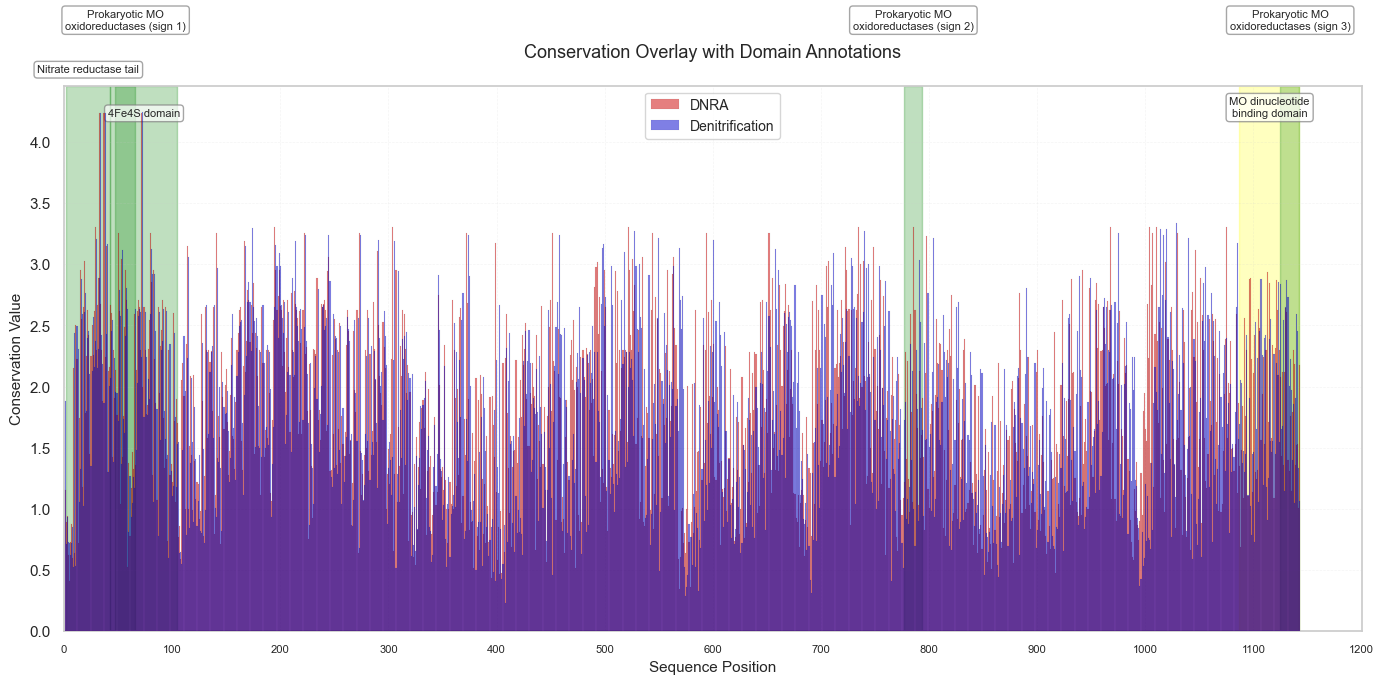

Data range: [1, 1143]
Nitrate reductase tail                        [   2-  43] → ✓
4Fe4S domain                                  [  43- 105] → ✓
MO dinucleotide
binding domain                [1087-1203] → ⚠ clipped to [1087, 1143]
Prokaryotic MO
oxidoreductases (sign 1)       [  48-  66] → ✓
Prokaryotic MO
oxidoreductases (sign 2)       [ 777- 794] → ✓
Prokaryotic MO
oxidoreductases (sign 3)       [1125-1152] → ⚠ clipped to [1125, 1143]


In [130]:
import numpy as np
import matplotlib.pyplot as plt

# Load and align data
conservation_dnra = np.load('../data/conservation_dnra.npy')
conservation_denitrification = np.load('../data/conservation_denitrification.npy')

min_len = min(len(conservation_dnra), len(conservation_denitrification))
conservation_dnra = conservation_dnra[:min_len]
conservation_denitrification = conservation_denitrification[:min_len]
x = np.arange(1, min_len + 1)  # Sequence positions (1-based)

# === KEY FIX: Define data bounds for clipping ===
DATA_START, DATA_END = 1, min_len

# Regions to highlight: [label, (start, end), color, v_offset, show_label]
regions_to_mark = [
    ["Nitrate reductase tail", (2, 43), "green", 0, True],
    ["4Fe4S domain", (43, 105), "green", -1, True],
    ["MO dinucleotide\nbinding domain", (1087, 1203), "yellow", -1, True],
    ["Prokaryotic MO\noxidoreductases (sign 1)", (48, 66), "green", 1, True],
    ["Prokaryotic MO\noxidoreductases (sign 2)", (777, 794), "green", 1, True],
    ["Prokaryotic MO\noxidoreductases (sign 3)", (1125, 1152), "green", 1, True],
]

fig, ax = plt.subplots(figsize=(14, 7))

# === STEP 1: Draw background regions (CLIPPED to data range) ===
for label, (start, end), color, v_offset, show_label in regions_to_mark:
    # Clip region to actual data bounds
    start_clipped = max(start, DATA_START)
    end_clipped = min(end, DATA_END)
    
    # Skip if region is entirely outside data range
    if start_clipped >= end_clipped:
        continue
    
    # Draw shaded region: shift by -0.5 to align with bar edges
    ax.axvspan(start_clipped - 0.5, end_clipped - 0.5,
               color=color, alpha=0.25, zorder=0)
    
    # Add label above plot area (use clipped midpoint for positioning)
    if show_label:
        mid = (start_clipped + end_clipped) / 2
        ax.text(mid, 1.02 + v_offset*0.08, label, 
                ha='center', va='bottom', fontsize=8,
                transform=ax.get_xaxis_transform(),
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                          edgecolor='gray', alpha=0.7))

# === STEP 2: Draw bars aligned with integer grid ===
bar_width = 1.0

ax.bar(x, conservation_dnra, width=bar_width, color='#CC0000', alpha=0.5, 
       label='DNRA', edgecolor='black', linewidth=0.05, zorder=3, align='center')
ax.bar(x, conservation_denitrification, width=bar_width, color='#0000CC', alpha=0.5, 
       label='Denitrification', edgecolor='black', linewidth=0.05, zorder=3, align='center')

# === STEP 3: Polish plot ===
# Set limits to match data range (with 0.5 padding for full bar visibility)
ax.set_xlim(DATA_START - 0.5, DATA_END + 0.5)

ax.set_xlabel('Sequence Position', fontsize=11)
ax.set_ylabel('Conservation Value', fontsize=11)
ax.set_title('Conservation Overlay with Domain Annotations', fontsize=13, pad=20)
ax.legend(frameon=True, fancybox=True, shadow=False, fontsize=10)

# Show grid for alignment reference
ax.grid(axis='both', alpha=0.2, zorder=1, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

# Optional: improve x-axis ticks
ax.tick_params(axis='x', labelsize=8)
ax.set_xticks(np.arange(0, min_len + 100, 100))

plt.tight_layout()
plt.show()

# === Diagnostic: Print clipping info ===
print(f"Data range: [{DATA_START}, {DATA_END}]")
for label, (start, end), *_ in regions_to_mark:
    s_clip = max(start, DATA_START)
    e_clip = min(end, DATA_END)
    status = "✓" if (s_clip, e_clip) == (start, end) else f"⚠ clipped to [{s_clip}, {e_clip}]"
    print(f"{label:45s} [{start:4d}-{end:4d}] → {status}")

repeat but with binning

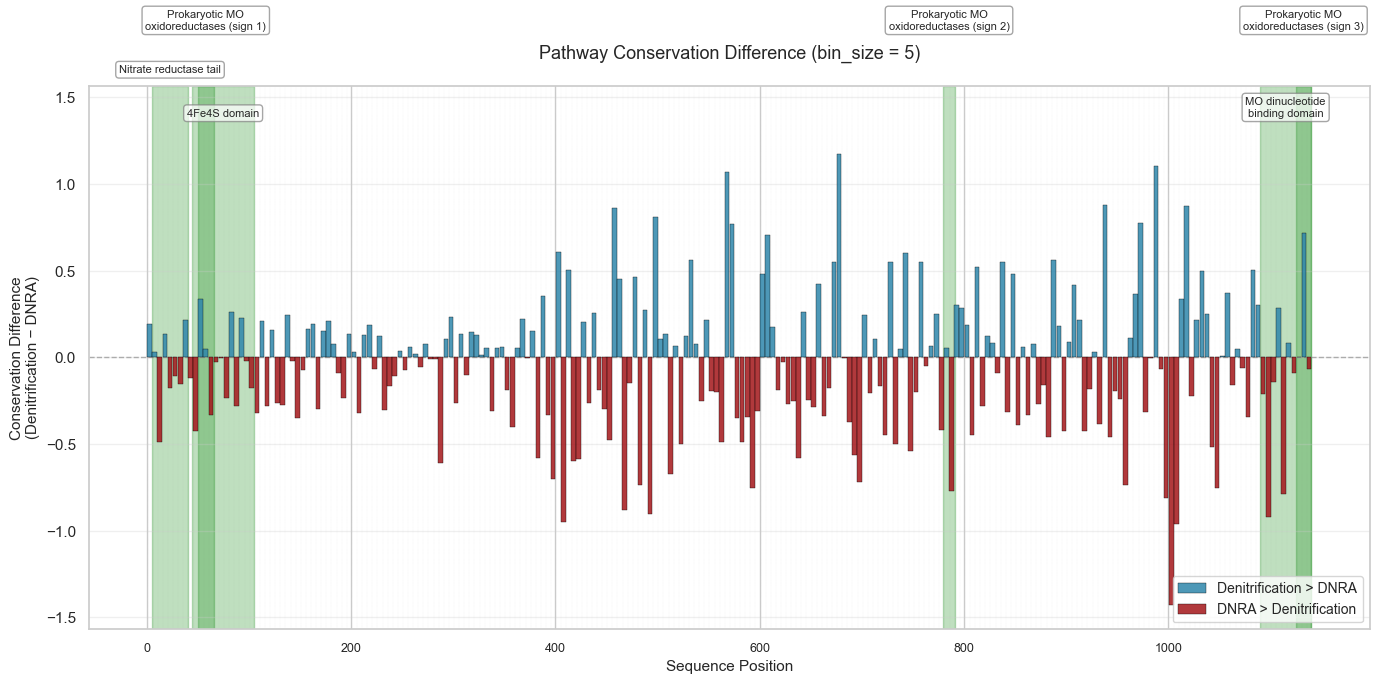

✓ Data length: 1143
✓ Bin size: 5
✓ Number of bins: 228
✓ Regions snapped to bins: True
✓ Difference range: -1.4256 to 1.1729


In [137]:
import numpy as np
import matplotlib.pyplot as plt

# ===========================
# 🔧 TUNABLE PARAMETERS
# ===========================
bin_size = 5                # Adjust binning resolution (3, 5, 10, 20, etc.)
snap_regions_to_bins = True   # Set True to align regions with bin edges

# ===========================
# 📥 LOAD & PREPARE DATA
# ===========================
conservation_dnra = np.load('../data/conservation_dnra.npy')
conservation_denitrification = np.load('../data/conservation_denitrification.npy')

# Align lengths
min_len = min(len(conservation_dnra), len(conservation_denitrification))
conservation_dnra = conservation_dnra[:min_len]
conservation_denitrification = conservation_denitrification[:min_len]
x_original = np.arange(1, min_len + 1)  # 1-based sequence positions

# ===========================
# 📦 BINNING FUNCTION
# ===========================
def bin_data(x, y, bin_size):
    """Bin 1D data by averaging over windows of size bin_size."""
    n = len(y)
    trim_len = (n // bin_size) * bin_size
    x_trim = x[:trim_len]
    y_trim = y[:trim_len]
    
    x_reshaped = x_trim.reshape(-1, bin_size)
    y_reshaped = y_trim.reshape(-1, bin_size)
    
    bin_means = y_reshaped.mean(axis=1)
    bin_edges = x_reshaped[:, [0, -1]]  # [start, end] of each bin
    bin_centers = (bin_edges[:, 0] + bin_edges[:, 1]) / 2
    
    return bin_centers, bin_means, bin_edges

# Apply binning
x_dnra_binned, y_dnra_binned, edges_dnra = bin_data(x_original, conservation_dnra, bin_size)
x_denit_binned, y_denit_binned, edges_denit = bin_data(x_original, conservation_denitrification, bin_size)

# ===========================
# 📊 CALCULATE DIFFERENCE
# ===========================
# Positive = Denitrification > DNRA (blue, up)
# Negative = DNRA > Denitrification (red, down)
difference = y_denit_binned - y_dnra_binned

# ===========================
# 🎨 REGIONS TO HIGHLIGHT
# ===========================
regions_to_mark = [
    ["Nitrate reductase tail", (2, 43), "green", 0, True],
    ["4Fe4S domain", (43, 105), "green", -1, True],
    # ["MO oxidoreductase\ndomain", (108, 833), "green", 0, False],
    ["MO dinucleotide\nbinding domain", (1087, 1203), "green", -1, True],
    ["Prokaryotic MO\noxidoreductases (sign 1)", (48, 66), "green", 1, True],
    ["Prokaryotic MO\noxidoreductases (sign 2)", (777, 794), "green", 1, True],
    ["Prokaryotic MO\noxidoreductases (sign 3)", (1125, 1152), "green", 1, True],
]



# ===========================
# 🔧 REGION SNAPPING HELPER
# ===========================
def snap_region_to_bins(region_start, region_end, bin_edges):
    """Snap region boundaries to nearest bin edges for perfect alignment."""
    all_edges = np.unique(bin_edges.flatten())
    # Find closest bin edge ≥ start
    snapped_start = all_edges[np.searchsorted(all_edges, region_start, side='left')]
    # Find closest bin edge ≤ end
    snapped_end = all_edges[np.searchsorted(all_edges, region_end, side='right') - 1]
    return snapped_start, snapped_end

# ===========================
# 📈 PLOTTING
# ===========================
fig, ax = plt.subplots(figsize=(14, 7))

# --- STEP 1: Background regions (snapped to bin edges if enabled) ---
for label, (start, end), color, v_offset, show_label in regions_to_mark:
    # Snap to bin edges for alignment
    if snap_regions_to_bins:
        start, end = snap_region_to_bins(start, end, edges_dnra)
    
    # Resolve color
    bg_color = color if isinstance(color, str) else color_map.get(color, '#F0F0F0')
    
    # Draw shaded region behind bars
    ax.axvspan(start, end, color=bg_color, alpha=0.25, zorder=0)
    
    # Add label above plot area
    if show_label:
        mid = (start + end) / 2
        ax.text(mid, 1.02 + v_offset*0.08, label, 
                ha='center', va='bottom', fontsize=8,
                transform=ax.get_xaxis_transform(),
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                          edgecolor='gray', alpha=0.7))

# --- STEP 2: Add bin edge guides (optional visual aid) ---
for start, end in edges_dnra:
    ax.axvline(start, color='gray', linewidth=0.3, alpha=0.2, zorder=1, linestyle=':')

# --- STEP 3: Diverging bars (difference plot) ---
bar_width = bin_size * 0.9  # Slightly less than bin_size to show edges

# Separate positive/negative for coloring
positive_mask = difference >= 0
negative_mask = difference < 0

# Blue bars up (denitrification dominates)
ax.bar(x_dnra_binned[positive_mask], difference[positive_mask], 
       width=bar_width, color='#2E86AB', alpha=0.85, 
       label='Denitrification > DNRA', edgecolor='black', linewidth=0.3, zorder=3)

# Red bars down (DNRA dominates)
ax.bar(x_dnra_binned[negative_mask], difference[negative_mask], 
       width=bar_width, color='#A4161A', alpha=0.85, 
       label='DNRA > Denitrification', edgecolor='black', linewidth=0.3, zorder=3)

# --- STEP 4: Zero reference line ---
ax.axhline(0, color='gray', linewidth=1, linestyle='--', zorder=2, alpha=0.6)

# --- STEP 5: Polish ---
ax.set_xlabel('Sequence Position', fontsize=11)
ax.set_ylabel('Conservation Difference\n(Denitrification − DNRA)', fontsize=11)
ax.set_title(f'Pathway Conservation Difference (bin_size = {bin_size})', fontsize=13, pad=20)
ax.legend(frameon=True, fancybox=True, fontsize=10, loc='lower right')
ax.grid(axis='y', alpha=0.3, zorder=1)
ax.set_axisbelow(True)

# Symmetric y-limits for visual balance
y_max = np.max(np.abs(difference)) * 1.1
ax.set_ylim(-y_max, y_max)

# Smarter x-ticks for long sequences
if min_len > 200:
    ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.show()

# ===========================
# 📋 DIAGNOSTIC OUTPUT (optional)
# ===========================
print(f"✓ Data length: {min_len}")
print(f"✓ Bin size: {bin_size}")
print(f"✓ Number of bins: {len(x_dnra_binned)}")
print(f"✓ Regions snapped to bins: {snap_regions_to_bins}")
print(f"✓ Difference range: {difference.min():.4f} to {difference.max():.4f}")